In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib as mpl
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
# try:
#     from cellacdc import cca_functions
#     from cellacdc import myutils
# except FileNotFoundError:
#     # Check if user has developer version --> add the Cell_ACDC/cellacdc
#     # folder to path and import from thre
#     sys.path.insert(0, '../cellacdc/')
#     from cellacdc import cca_functions
#     from cellacdc import myutils

# ***Import nutrient switch data - two reps - and concatenate*** 
# ***-update f_pos_cell_id with additional rep***

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


rep1_rel_switch_wave_df= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\07032025_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
rep1_rel_switch_wave_df['rep'] = 1
rep1_rel_switch_wave_df = rep1_rel_switch_wave_df.drop(['Unnamed: 0'], axis=1)
print(rep1_rel_switch_wave_df.shape)
#display(rep1_rel_switch_wave_df.head(5))

rep2_rel_switch_wave_df= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\27032025_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
rep2_rel_switch_wave_df['rep'] = 2
rep2_rel_switch_wave_df = rep2_rel_switch_wave_df.drop(['Unnamed: 0'], axis=1)
print(rep2_rel_switch_wave_df.shape) 
#display(rep2_rel_switch_wave_df.head(5))


rep_df_list = [rep1_rel_switch_wave_df, rep2_rel_switch_wave_df]
overall_df_with_rel_and_switch_info = pd.concat(rep_df_list).reset_index(drop = True)
print(overall_df_with_rel_and_switch_info.shape)
overall_df_with_rel_and_switch_info['rep_str_pos_cell_id'] = overall_df_with_rel_and_switch_info.apply(lambda x: f'{x["f_pos_cell_id"]}_Rep_{int(x["rep"])}', axis=1)
overall_df_with_rel_and_switch_info = overall_df_with_rel_and_switch_info.drop(['f_pos_cell_id'], axis=1)
overall_df_with_rel_and_switch_info = overall_df_with_rel_and_switch_info.rename(columns={"rep_str_pos_cell_id": "f_pos_cell_id"})
#display(overall_df_with_rel_and_switch_info.head(5))
print(overall_df_with_rel_and_switch_info.rep.unique())
display(overall_df_with_rel_and_switch_info.drop(columns = ['directory']).head(10))

C:\Users\timon\AppData\Local\Temp\ipykernel_24944\2237762626.py:6: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  rep1_rel_switch_wave_df= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\07032025_jupyter_overall_df_with_rel_switch_and_wave_info.csv")


(156030, 391)


C:\Users\timon\AppData\Local\Temp\ipykernel_24944\2237762626.py:12: DtypeWarning: Columns (375) have mixed types. Specify dtype option on import or set low_memory=False.
  rep2_rel_switch_wave_df= pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\27032025_jupyter_overall_df_with_rel_switch_and_wave_info.csv")


(169317, 395)
(325347, 397)
[1 2]


,frame_i,Cell_ID,time_seconds,time_minutes,time_hours,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,will_divide,daughter_disappears_before_division,disappears_before_division,is_cell_dead,is_cell_excluded,was_manually_edited,index,Dia_Ph3_mCherry_CV,Dia_Ph3_mCherry_amount_autoBkgr,Dia_Ph3_mCherry_amount_dataPrepBkgr,Dia_Ph3_mCherry_amount_manualBkgr,Dia_Ph3_mCherry_autoBkgr_bkgrVal_mean,Dia_Ph3_mCherry_autoBkgr_bkgrVal_median,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q05,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q25,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q75,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q95,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_fl,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_vox,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_fl,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_vox,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_mean,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_median,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q05,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q25,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q75,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q95,Dia_Ph3_mCherry_manualBkgr_bkgrVal_mean,Dia_Ph3_mCherry_manualBkgr_bkgrVal_median,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q05,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q25,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q75,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q95,Dia_Ph3_mCherry_max,Dia_Ph3_mCherry_mean,Dia_Ph3_mCherry_mean_manualBkgr,Dia_Ph3_mCherry_median,Dia_Ph3_mCherry_min,Dia_Ph3_mCherry_q05,Dia_Ph3_mCherry_q25,Dia_Ph3_mCherry_q75,Dia_Ph3_mCherry_q95,Dia_Ph3_mCherry_sum,bbox,cell_area_pxl,cell_area_um2,cell_vol_fl,cell_vol_vox,centroid,inertia_tensor,inertia_tensor_eigvals,label,local_centroid,moments,moments_central,moments_normalized,num_objects,velocity_pixel,velocity_um,x_centroid,y_centroid,major_axis_length_gui,minor_axis_length_gui,inertia_tensor_eigvals-0,inertia_tensor_eigvals-1,equivalent_diameter,moments-0-0,moments-0-1,moments-0-2,moments-0-3,moments-1-0,moments-1-1,moments-1-2,moments-1-3,moments-2-0,moments-2-1,moments-2-2,moments-2-3,moments-3-0,moments-3-1,moments-3-2,moments-3-3,area_gui,solidity_gui,extent,inertia_tensor-0-0,inertia_tensor-0-1,inertia_tensor-1-0,inertia_tensor-1-1,filled_area_gui,centroid-0,centroid-1,bbox_area,local_centroid-0,local_centroid-1,convex_area_gui,euler_number,moments_normalized-0-0,moments_normalized-0-1,moments_normalized-0-2,moments_normalized-0-3,moments_normalized-1-0,moments_normalized-1-1,moments_normalized-1-2,moments_normalized-1-3,moments_normalized-2-0,moments_normalized-2-1,moments_normalized-2-2,moments_normalized-2-3,moments_normalized-3-0,moments_normalized-3-1,moments_normalized-3-2,moments_normalized-3-3,moments_central-0-0,moments_central-0-1,moments_central-0-2,moments_central-0-3,moments_central-1-0,moments_central-1-1,moments_central-1-2,moments_central-1-3,moments_central-2-0,moments_central-2-1,moments_central-2-2,moments_central-2-3,moments_central-3-0,moments_central-3-1,moments_central-3-2,moments_central-3-3,bbox-0,bbox-1,bbox-2,bbox-3,end_of_cell_cycle_frame_i,area,convex_area,filled_area,major_axis_length,minor_axis_length,orientation,perimeter,centroid_y,centroid_x,solidity,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_mCherry_corrected_mean,Dia_Ph3_mCherry_raw_sum,Dia_Ph3_mCherry_corrected_amount,Dia_Ph3_mCherry_corrected_concentration,max_frame_pos,file,selection_subset,position,Cell_ID_rel,time_seconds_rel,time_minutes_rel,time_hours_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,will_divide_rel,daughter_disappears_before_division_rel,disappears_before_division_rel,is_cell_dead_rel,is_cell_excluded_rel,was_manually_edited_rel,index_rel,Dia_Ph3_mCherry_CV_rel,Dia_Ph3_mCherry_amount_autoBkgr_rel,Dia_Ph3_mCherry_amount_dataPrepBkgr_rel,Dia_Ph3_mCherry_amount_manualBkgr_rel,Dia_Ph3_m

In [5]:
# print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 3].S_switch_cells_daughter_wave.unique())
# print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 3].G1_switch_cells_daughter_wave.unique())
# print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 3].complete_phase.unique())

print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 2].post_switch_gen.unique())
print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 1].post_switch_gen.unique())

overall_df_with_rel_and_switch_info.loc[(((overall_df_with_rel_and_switch_info['rep'] == 1) | (overall_df_with_rel_and_switch_info['rep'] == 2))
                                & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == '0.0') | (overall_df_with_rel_and_switch_info['post_switch_gen'] == 0))), 
                               'post_switch_gen'] = 0.0
overall_df_with_rel_and_switch_info.loc[(((overall_df_with_rel_and_switch_info['rep'] == 1) | (overall_df_with_rel_and_switch_info['rep'] == 2))
                                & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == '1.0') | (overall_df_with_rel_and_switch_info['post_switch_gen'] == 1))), 
                               'post_switch_gen'] = 1.0
overall_df_with_rel_and_switch_info.loc[(((overall_df_with_rel_and_switch_info['rep'] == 1) | (overall_df_with_rel_and_switch_info['rep'] == 2))
                                & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == '2.0') | (overall_df_with_rel_and_switch_info['post_switch_gen'] == 2))), 
                               'post_switch_gen'] = 2.0
overall_df_with_rel_and_switch_info.loc[(((overall_df_with_rel_and_switch_info['rep'] == 1) | (overall_df_with_rel_and_switch_info['rep'] == 2))
                                & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == '3.0') | (overall_df_with_rel_and_switch_info['post_switch_gen'] == 3))), 
                               'post_switch_gen'] = 3.0
overall_df_with_rel_and_switch_info.loc[(((overall_df_with_rel_and_switch_info['rep'] == 1) | (overall_df_with_rel_and_switch_info['rep'] == 2))
                                & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == '4.0') | (overall_df_with_rel_and_switch_info['post_switch_gen'] == 4))), 
                               'post_switch_gen'] = 4.0
overall_df_with_rel_and_switch_info.loc[(((overall_df_with_rel_and_switch_info['rep'] == 1) | (overall_df_with_rel_and_switch_info['rep'] == 2))
                                & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == '5.0') | (overall_df_with_rel_and_switch_info['post_switch_gen'] == 5))), 
                               'post_switch_gen'] = 5.0
overall_df_with_rel_and_switch_info.loc[(((overall_df_with_rel_and_switch_info['rep'] == 1) | (overall_df_with_rel_and_switch_info['rep'] == 2))
                                & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == '6.0') | (overall_df_with_rel_and_switch_info['post_switch_gen'] == 6))), 
                               'post_switch_gen'] = 6.0

print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 2].post_switch_gen.unique())
print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 1].post_switch_gen.unique())


print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 2].S_switch_cells_daughter_wave.unique())
print(overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['rep'] == 1].S_switch_cells_daughter_wave.unique())

[nan 'switch_gen' '1.0' '2.0' '3.0' '0.0' '4.0' '5.0' 0.0 1.0 2.0 3.0 4.0
 5.0]
[nan 'switch_gen' '1.0' '2.0' '3.0' '4.0' '0.0' '5.0' 0.0 1.0 2.0 3.0]
[nan 'switch_gen' 1.0 2.0 3.0 0.0 4.0 5.0]
[nan 'switch_gen' 1.0 2.0 3.0 4.0 0.0 5.0]
[nan  1.  2.  3.  4.  5.]
[nan  1.  2.  3.  4.]


# ***calculating volume added between two frames for each cell***


In [6]:
overall_df_with_rel_and_switch_info.reset_index(drop=True, inplace=True)
# display(overall_df_with_rel_and_switch_info.head(5))

import warnings

with warnings.catch_warnings(record=True):
    unique_f_pos_cell_id = []
    for fposid in ((overall_df_with_rel_and_switch_info['f_pos_cell_id']).unique()):
        fposid_df = overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['f_pos_cell_id'] == fposid]
        fposid_df = fposid_df.sort_values(by=['frame_i'])
        min_frame = fposid_df.frame_i.min()
        fposid_df["vol_added_since_prev_frame_fl"] = np.nan
        for row in fposid_df.index:
            frame = fposid_df.loc[row,'frame_i']
            if frame  == min_frame:
                fposid_df["vol_added_since_prev_frame_fl"].loc[row] = np.nan
            else:
                fposid_df["vol_added_since_prev_frame_fl"].loc[row] = (fposid_df["combined_mother_bud_volume"].loc[row])-(fposid_df["combined_mother_bud_volume"].loc[row-1])
        unique_f_pos_cell_id.append(fposid_df)
        
overall_df_with_rel_and_switch_info = pd.concat(unique_f_pos_cell_id)


# ***Assigning delta vol normalised to cell vol for both data*** 

In [7]:
overall_df_with_rel_and_switch_info['delta_vol_norm_cellvol'] = (overall_df_with_rel_and_switch_info['vol_added_since_prev_frame_fl']/overall_df_with_rel_and_switch_info['combined_mother_bud_volume'])

In [9]:
overall_df_with_rel_and_switch_info.to_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\MetprCln311Arepscombined_jupyter_overall_df_with_rel_switch_and_wave_info.csv")

In [10]:
# display(overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['S_switch_cells_daughter_wave'] == 5) 
#                                                                                     & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == 1.0)|
#                                                                                        (overall_df_with_rel_and_switch_info['post_switch_gen'] == "1"))
#                                                                                     & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
#                                                                                     & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
#                                                                                     #& (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
#                                                                                    ])

# display(overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['S_switch_cells_daughter_wave'] == 5) & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == 'G1')])

# ***Daughters of S/G2/M switchers*** 
#  ***VOL ADDED IN G1 PLOT***

,frame_i,Cell_ID,time_seconds,time_minutes,time_hours,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,will_divide,daughter_disappears_before_division,disappears_before_division,is_cell_dead,is_cell_excluded,was_manually_edited,index,Dia_Ph3_mCherry_CV,Dia_Ph3_mCherry_amount_autoBkgr,Dia_Ph3_mCherry_amount_dataPrepBkgr,Dia_Ph3_mCherry_amount_manualBkgr,Dia_Ph3_mCherry_autoBkgr_bkgrVal_mean,Dia_Ph3_mCherry_autoBkgr_bkgrVal_median,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q05,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q25,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q75,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q95,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_fl,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_vox,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_fl,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_vox,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_mean,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_median,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q05,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q25,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q75,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q95,Dia_Ph3_mCherry_manualBkgr_bkgrVal_mean,Dia_Ph3_mCherry_manualBkgr_bkgrVal_median,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q05,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q25,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q75,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q95,Dia_Ph3_mCherry_max,Dia_Ph3_mCherry_mean,Dia_Ph3_mCherry_mean_manualBkgr,Dia_Ph3_mCherry_median,Dia_Ph3_mCherry_min,Dia_Ph3_mCherry_q05,Dia_Ph3_mCherry_q25,Dia_Ph3_mCherry_q75,Dia_Ph3_mCherry_q95,Dia_Ph3_mCherry_sum,bbox,cell_area_pxl,cell_area_um2,cell_vol_fl,cell_vol_vox,centroid,inertia_tensor,inertia_tensor_eigvals,label,local_centroid,moments,moments_central,moments_normalized,num_objects,velocity_pixel,velocity_um,x_centroid,y_centroid,major_axis_length_gui,minor_axis_length_gui,inertia_tensor_eigvals-0,inertia_tensor_eigvals-1,equivalent_diameter,moments-0-0,moments-0-1,moments-0-2,moments-0-3,moments-1-0,moments-1-1,moments-1-2,moments-1-3,moments-2-0,moments-2-1,moments-2-2,moments-2-3,moments-3-0,moments-3-1,moments-3-2,moments-3-3,area_gui,solidity_gui,extent,inertia_tensor-0-0,inertia_tensor-0-1,inertia_tensor-1-0,inertia_tensor-1-1,filled_area_gui,centroid-0,centroid-1,bbox_area,local_centroid-0,local_centroid-1,convex_area_gui,euler_number,moments_normalized-0-0,moments_normalized-0-1,moments_normalized-0-2,moments_normalized-0-3,moments_normalized-1-0,moments_normalized-1-1,moments_normalized-1-2,moments_normalized-1-3,moments_normalized-2-0,moments_normalized-2-1,moments_normalized-2-2,moments_normalized-2-3,moments_normalized-3-0,moments_normalized-3-1,moments_normalized-3-2,moments_normalized-3-3,moments_central-0-0,moments_central-0-1,moments_central-0-2,moments_central-0-3,moments_central-1-0,moments_central-1-1,moments_central-1-2,moments_central-1-3,moments_central-2-0,moments_central-2-1,moments_central-2-2,moments_central-2-3,moments_central-3-0,moments_central-3-1,moments_central-3-2,moments_central-3-3,bbox-0,bbox-1,bbox-2,bbox-3,end_of_cell_cycle_frame_i,area,convex_area,filled_area,major_axis_length,minor_axis_length,orientation,perimeter,centroid_y,centroid_x,solidity,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_mCherry_corrected_mean,Dia_Ph3_mCherry_raw_sum,Dia_Ph3_mCherry_corrected_amount,Dia_Ph3_mCherry_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,Cell_ID_rel,time_seconds_rel,time_minutes_rel,time_hours_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,will_divide_rel,daughter_disappears_before_division_rel,disappears_before_division_rel,is_cell_dead_rel,is_cell_excluded_rel,was_manually_edited_rel,index_rel,Dia_Ph3_mCherry_CV_rel,Dia_Ph3_mCherry_amount_autoBkgr_rel,Dia_Ph3_mCherry_amount_dataPrepBkgr_rel,Dia_Ph3_mCherry_amount_manualBkgr_rel

,frame_i,Cell_ID,time_seconds,time_minutes,time_hours,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,will_divide,daughter_disappears_before_division,disappears_before_division,is_cell_dead,is_cell_excluded,was_manually_edited,index,Dia_Ph3_mCherry_CV,Dia_Ph3_mCherry_amount_autoBkgr,Dia_Ph3_mCherry_amount_dataPrepBkgr,Dia_Ph3_mCherry_amount_manualBkgr,Dia_Ph3_mCherry_autoBkgr_bkgrVal_mean,Dia_Ph3_mCherry_autoBkgr_bkgrVal_median,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q05,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q25,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q75,Dia_Ph3_mCherry_autoBkgr_bkgrVal_q95,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_fl,Dia_Ph3_mCherry_concentration_autoBkgr_from_vol_vox,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_fl,Dia_Ph3_mCherry_concentration_dataPrepBkgr_from_vol_vox,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_mean,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_median,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q05,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q25,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q75,Dia_Ph3_mCherry_dataPrepBkgr_bkgrVal_q95,Dia_Ph3_mCherry_manualBkgr_bkgrVal_mean,Dia_Ph3_mCherry_manualBkgr_bkgrVal_median,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q05,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q25,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q75,Dia_Ph3_mCherry_manualBkgr_bkgrVal_q95,Dia_Ph3_mCherry_max,Dia_Ph3_mCherry_mean,Dia_Ph3_mCherry_mean_manualBkgr,Dia_Ph3_mCherry_median,...,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,phase_Dia_Ph3_mCherry_amount_at_beginning,phase_Dia_Ph3_mCherry_mean_at_beginning,phase_Dia_Ph3_mCherry_concentration_at_beginning,phase_Dia_Ph3_mCherry_concentration_at_end,phase_Dia_Ph3_mCherry_combined_amount_at_beginning,phase_Dia_Ph3_mCherry_combined_amount_at_end,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,does_cell_die_in_this_phase,S_switch_cells_daughter_wave,G1_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,rep,corrected_on_frame_i,basename,disappears_before_end,corrected_on_frame_i_rel,basename_rel,disappears_before_end_rel,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol
0,10,2,1800.0,30.0,0.50,G1,1.0,3.0,mother,-1.0,10.0,0.0,0.0,1.0,0.0,0.0,0,0,0,53,0.492171,878507.0,733507.0,7.238669e+05,1045.819923,1045.0,865.0,974.0,1121.0,1246.0,12294.766348,7.984982,10265.481299,6.667039,1098.324157,1095.0,935.00,1026.0,1166.00,1278.00,0.0,0.0,0.0,0.0,0.0,0.0,5937.0,1347.933448,249.609291,1133.5,...,21.748724,71.453737,72.658134,0.539968,2.810638,4,10,14,72.658134,1,1,869807.0,299.933448,12173.009245,14474.883245,869807.0,1051718.0,1,1.0,MMY,SCD,NaN,False,False,True,False,False,True,1.204397,0,0,NaN,1,0.0,10.0,71.453737,15.0,72.076636,34.0,112.771402,1,NaN,NaN,NaN,NaN,NaN,NaN,MMY_Position_1_Cell_2_Gen_1_Rep_1,NaN,NaN
1,21,6,3780.0,63.0,1.05,G1,1.0,4.0,mother,1.0,21.0,1.0,0.0,1.0,0.0,0.0,0,0,0,134,0.544819,1034179.0,923971.0,9.112524e+05,1045.082692,1042.0,861.0,970.0,1117.0,1245.0,21100.580052,13.704023,18851.982153,12.243644,1095.539479,1090.0,931.00,1023.0,1165.00,1270.00,0.0,0.0,0.0,0.0,0.0,0.0,6618.0,1492.426394,396.886914,1215.0,...,17.218990,49.011875,56.229173,-0.037498,0.057640,5,21,26,56.229173,1,1,1029587.0,448.426394,21006.888473,21139.026920,1029587.0,1188630.0,1,1.0,MMY,SCD,switch_gen,True,False,True,False,False,True,7.217298,0,0,NaN,1,0.0,21.0,49.011875,27.0,58.486409,88.0,93.443203,1,NaN,NaN,NaN,NaN,NaN,NaN,MMY_Position_1_Cell_6_Gen_1_Rep_1,NaN,NaN
2,32,14,5760.0,96.0,1.60,G1,1.0,3.0,mother,15.0,32.0,1.0,0.0,1.0,0.0,0.0,0,0,0,238,0.507550,666956.0,575646.0,5.610618e+05,1050.

C:\Users\timon\AppData\Local\Temp\ipykernel_24944\1931055482.py:60: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(x = "S_switch_cells_daughter_wave", y = "phase_volume_growth", hue = "strain",  data =preswitch_plus_postswitch,


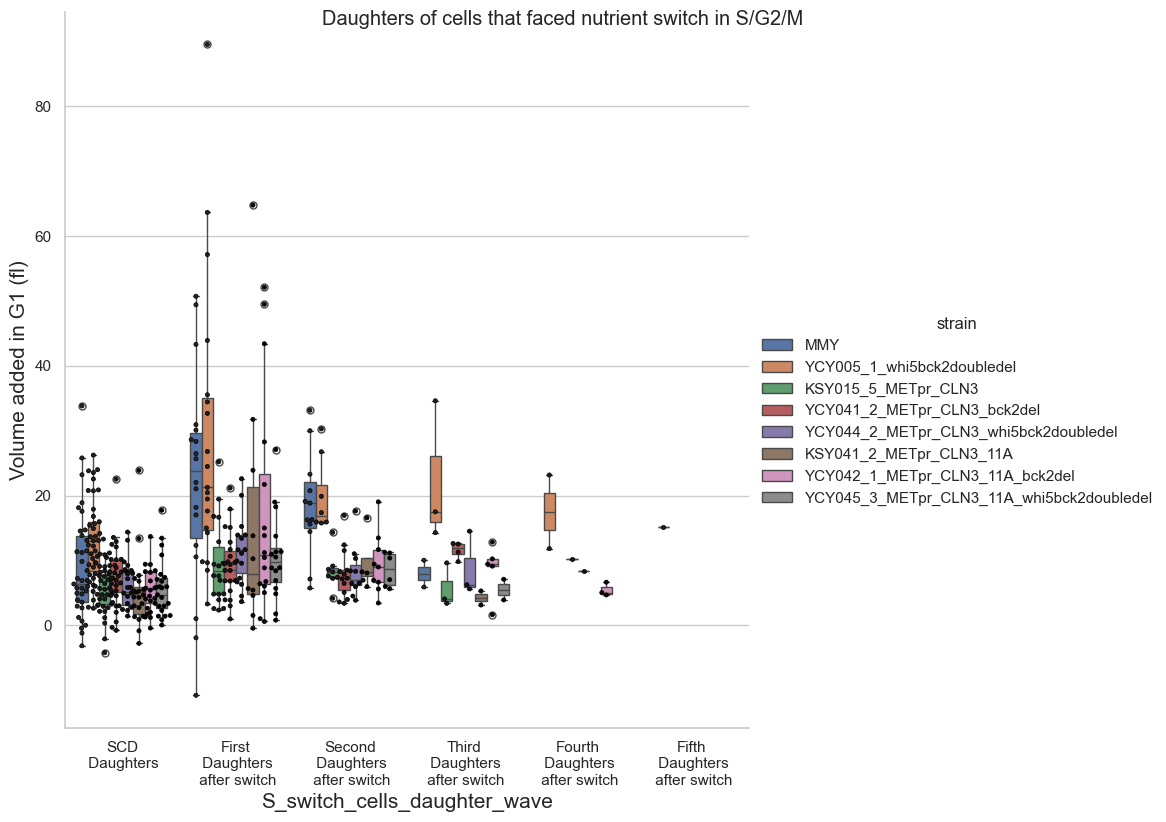

In [11]:
post_switch_daughters_complete_G1_df = overall_df_with_rel_and_switch_info[(np.isnan(overall_df_with_rel_and_switch_info['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == 1.0)|
                                                                                       (overall_df_with_rel_and_switch_info['post_switch_gen'] == "1"))
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    #& (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
                                                                                   ]
display(post_switch_daughters_complete_G1_df.head())
pre_switch_daughters_complete_G1_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['growthmedium'] == "SCD") 
                                                                                    & (overall_df_with_rel_and_switch_info['generation_num'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
                                                                                   ]
pd.set_option('display.max_rows', 350)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 300)
#display(post_switch_daughters_complete_G1_df.head(20))

#groupby unique f_pos_cell_id

unique_f_pos_cell_id = []
for fposid in ((post_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_daughters_complete_G1_df[post_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
unique_first_G1_frame_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)
#display(unique_first_G1_frame_df.head(10))

unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_daughters_complete_G1_df[pre_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
unique_first_G1_frame_df_pre['S_switch_cells_daughter_wave'] = 0
display(unique_first_G1_frame_df_pre.head(10))
preswitch_plus_postswitch = pd.concat([unique_first_G1_frame_df, unique_first_G1_frame_df_pre]).reset_index()
preswitch_plus_postswitch['G1_length_mins'] = (preswitch_plus_postswitch['phase_length'])*3
#sns.catplot(x = "switch_cells_daughter_wave", y = "phase_length", hue = "strain",  data =unique_first_G1_frame_df, kind = "box")

#palette ={"MMY": "silver", "WHI5DEL": "mediumturquoise", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "royalblue"}
sns.set_style("whitegrid")
a = sns.catplot(x = "S_switch_cells_daughter_wave", y = "phase_volume_growth",hue = "strain", data =preswitch_plus_postswitch, 
                kind = "box", 
                #palette = palette,
                hue_order = ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                height=8, aspect=1)
a.set_axis_labels("", "Volume added in G1 (fl)", size = 15)
a.fig.suptitle("Daughters of cells that faced nutrient switch in S/G2/M")
a.set_xticklabels(['SCD\n Daughters','First\n Daughters\n after switch','Second\n Daughters\n after switch','Third\n Daughters\n after switch','Fourth\n Daughters\n after switch', 'Fifth\n Daughters\n after switch'])
#a.set(ylim=(-10,400))
# a.set_xticklabels(size = 15)
# a.set_yticklabels(size = 15)
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Nutrient Switch\Igor's Microfluidics Nutrient Switch\S_G2_M switchers\131022_G1_vol_added_vs_daughter_wave.png")
sns.swarmplot(x = "S_switch_cells_daughter_wave", y = "phase_volume_growth", hue = "strain",  data =preswitch_plus_postswitch, 
              hue_order =  ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
              dodge = True, legend = False, edgecolor = "black", linewidth = 0.5, size = 3, color = 'black')
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Nutrient Switch\Igor's Microfluidics Nutrient Switch\S_G2_M switchers\131022_G1_vol_added_vs_daughter_wave_withswarm.png")



plt.show()

#  ***G1 LENGTH PLOT***

C:\Users\timon\AppData\Local\Temp\ipykernel_24944\1217402807.py:66: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(x = "S_switch_cells_daughter_wave", y = "G1_length_mins", hue = "strain",  data =preswitch_plus_postswitch,


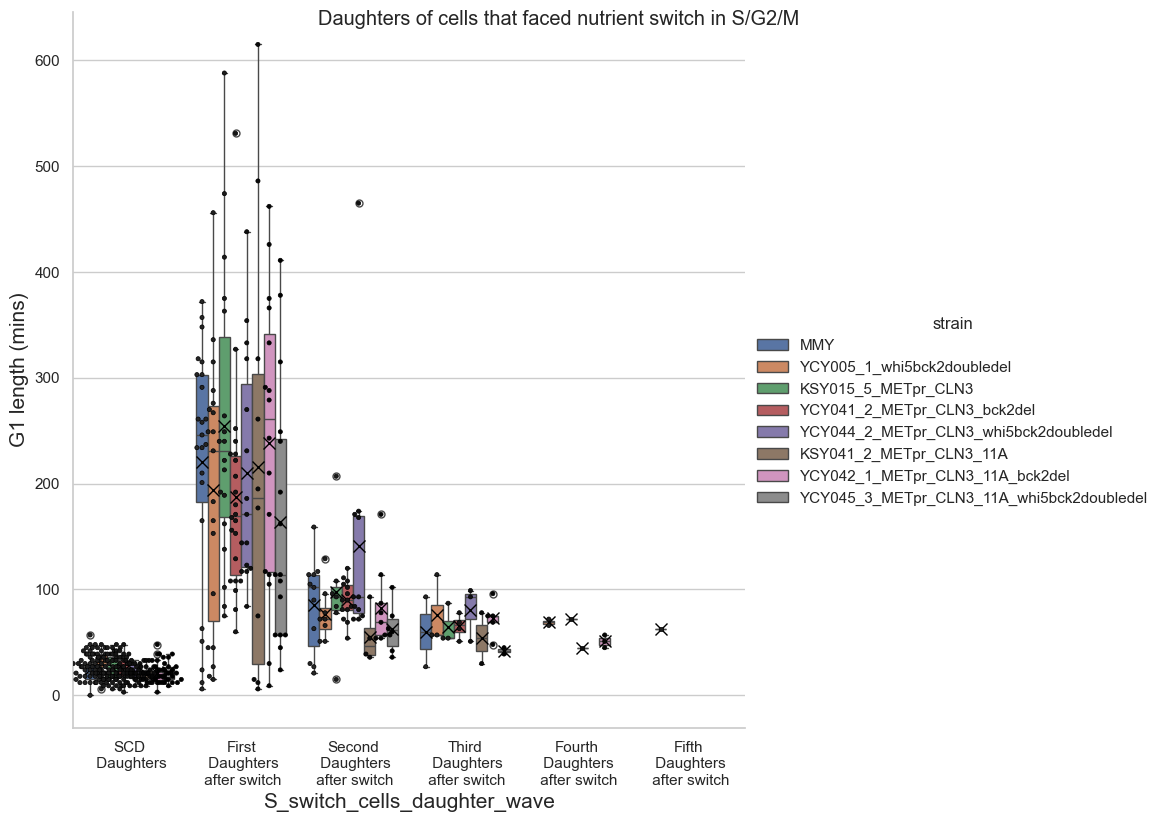

In [12]:
post_switch_daughters_complete_G1_df = overall_df_with_rel_and_switch_info[(np.isnan(overall_df_with_rel_and_switch_info['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == 1.0)|
                                                                                       (overall_df_with_rel_and_switch_info['post_switch_gen'] == "1"))
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    #& (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
                                                                                   ]

pre_switch_daughters_complete_G1_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['growthmedium'] == "SCD") 
                                                                                    & (overall_df_with_rel_and_switch_info['generation_num'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
                                                                                   ]
pd.set_option('display.max_rows', 350)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 300)
#display(post_switch_daughters_complete_G1_df.head(20))

#groupby unique f_pos_cell_id

unique_f_pos_cell_id = []
for fposid in ((post_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_daughters_complete_G1_df[post_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
unique_first_G1_frame_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)
#display(unique_first_G1_frame_df.head(10))

unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_daughters_complete_G1_df[pre_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
unique_first_G1_frame_df_pre['S_switch_cells_daughter_wave'] = 0
#display(unique_first_G1_frame_df_pre.head(10))
preswitch_plus_postswitch = pd.concat([unique_first_G1_frame_df, unique_first_G1_frame_df_pre])
preswitch_plus_postswitch['G1_length_mins'] = (preswitch_plus_postswitch['phase_length'])*3
#sns.catplot(x = "switch_cells_daughter_wave", y = "phase_length", hue = "strain",  data =unique_first_G1_frame_df, kind = "box")

#palette ={"MMY": "silver", "WHI5DEL": "mediumturquoise", "BCK2DEL": "mediumvioletred", "WHI5_BCK2_DD": "royalblue"}
sns.set_style("whitegrid")
a = sns.catplot(x = "S_switch_cells_daughter_wave", y = "G1_length_mins",hue = "strain", data =preswitch_plus_postswitch, 
                kind = "box", 
                showmeans = True,
                meanprops={"marker":"x","markerfacecolor":"white", "markeredgecolor":"black", "markeredgewidth":1, "markersize": 8},
                hue_order =  ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                height=8, aspect=1)
# a = sns.catplot(x = "S_switch_cells_daughter_wave", y = "G1_length_mins",hue = "strain", data =preswitch_plus_postswitch, 
#                 kind = "swarm", palette = palette, height=8, aspect=1, dodge = True)
a.set_axis_labels("", "G1 length (mins)", size = 15)
a.fig.suptitle("Daughters of cells that faced nutrient switch in S/G2/M")
a.set_xticklabels(['SCD\n Daughters','First\n Daughters\n after switch',
                   'Second\n Daughters\n after switch','Third\n Daughters\n after switch',
                   'Fourth\n Daughters\n after switch', 'Fifth\n Daughters\n after switch'])

#a.set(ylim=(-40,1200))
# a.set_xticklabels(size = 15)
# a.set_yticklabels(size = 15)
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Nutrient Switch\Igor's Microfluidics Nutrient Switch\S_G2_M switchers\131022_G1_length_vs_daughter_wave.png")
sns.swarmplot(x = "S_switch_cells_daughter_wave", y = "G1_length_mins", hue = "strain",  data =preswitch_plus_postswitch,
              hue_order = ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
              dodge = True, legend = False, edgecolor = "black", linewidth = 0.5, size = 3, color = "black")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Nutrient Switch\Igor's Microfluidics Nutrient Switch\S_G2_M switchers\131022_G1_length_vs_daughter_wave_withswarm.png")
# display(preswitch_plus_postswitch[(preswitch_plus_postswitch['position'] == "Position_27") 
#                                   & (preswitch_plus_postswitch['cell_cycle_stage'] != "S")
#                                   & (preswitch_plus_postswitch['complete_phase'] == 1)
#                                   & ((preswitch_plus_postswitch['post_switch_gen'] == "1")|
#                                      (preswitch_plus_postswitch['post_switch_gen'] == 1))
#                                   & (preswitch_plus_postswitch['G1_length_mins'] > 200)
#                                  ]
#                                   )
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Revision\METpr_CLN311A_nutrientswitch\repscombined_daughtersSG2Mswitchers_G1length.png", bbox_inches="tight")
plt.show()

# ***birth vol plots***


In [13]:
pre_switch_complete_G1_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['growthmedium'] == "SCD") 
                                                                                    #& (overall_df_with_rel_and_switch_info['generation_num'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
                                                                                    
                                                                                   ]
unique_f_pos_cell_id = []
for fposid in ((pre_switch_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_complete_G1_df[pre_switch_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
unique_first_G1_frame_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)



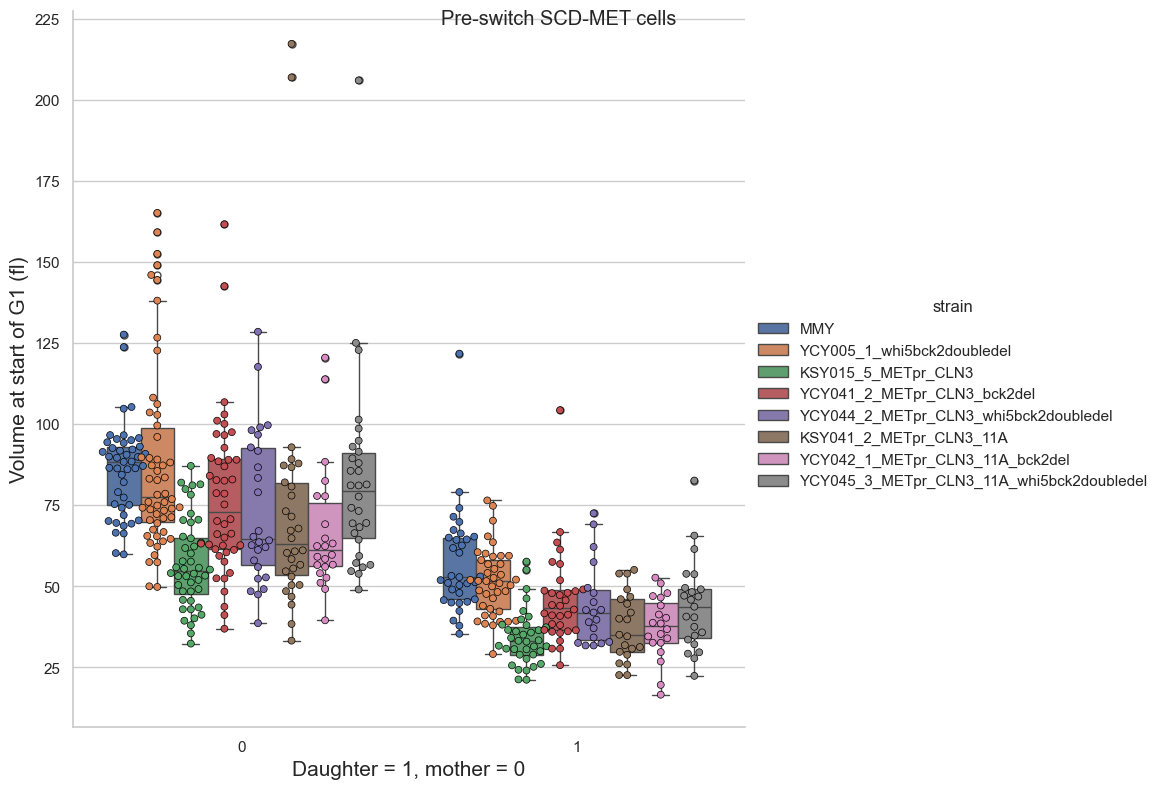

In [14]:


sns.set_style("whitegrid")

a = sns.catplot(x = "daughterhood_binary", y = "cell_vol_fl",hue = "strain", data =unique_first_G1_frame_df, 
                kind = "box", 
                #palette = palette,
                hue_order = ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                height=8, aspect=1)
a.set_axis_labels("Daughter = 1, mother = 0", "Volume at start of G1 (fl)", size = 15)
sns.swarmplot(x = "daughterhood_binary", y = "cell_vol_fl",hue = "strain", data =unique_first_G1_frame_df, 
              hue_order = ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
              dodge = True, legend = False, edgecolor = "black", linewidth = 0.5)
#
a.fig.suptitle("Pre-switch SCD-MET cells")
#a.set_xticklabels(['SCD\n Daughters','First\n Daughters\n after switch','Second\n Daughters\n after switch','Third\n Daughters\n after switch','Fourth\n Daughters\n after switch', 'Fifth\n Daughters\n after switch'])
#a.set(ylim=(-10,400))
# a.set_xticklabels(size = 15)
# a.set_yticklabels(size = 15)
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Revision\METpr_CLN311A_nutrientswitch\repscombined_preswitch_cellvol_birth.png")
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Nutrient Switch\Igor's Microfluidics Nutrient Switch\S_G2_M switchers\131022_G1_vol_added_vs_daughter_wave_withswarm.png")



plt.show()

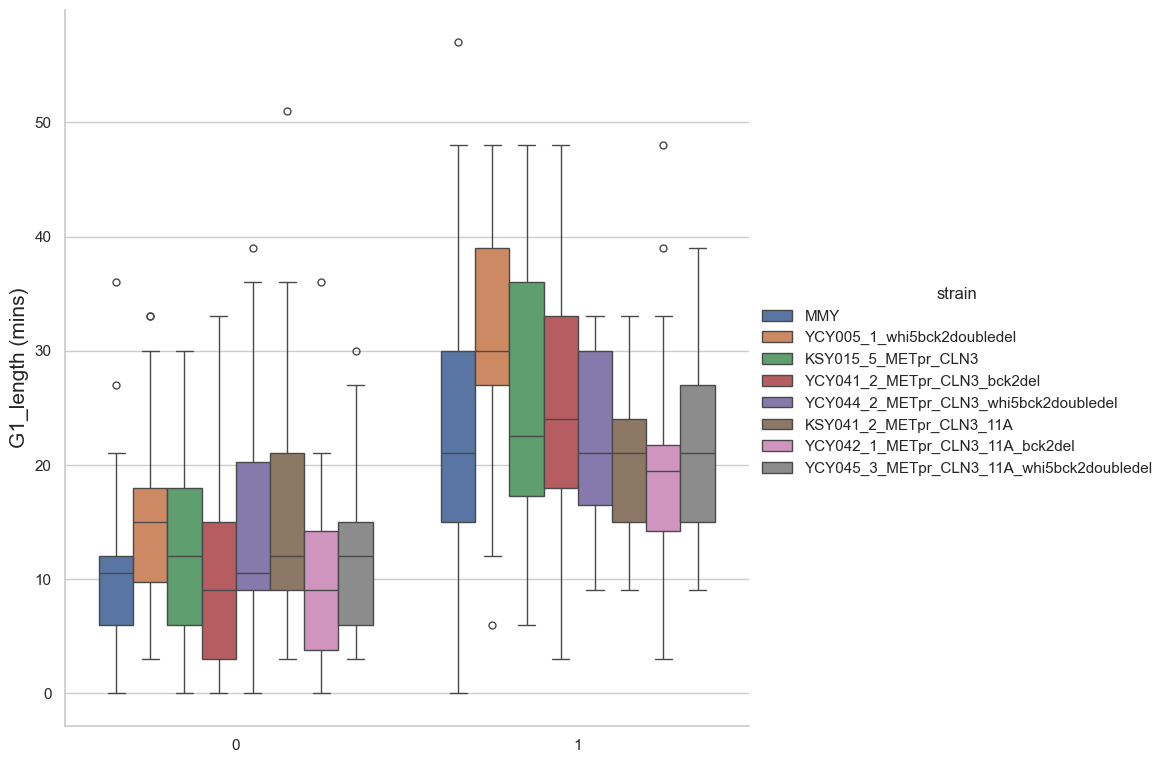

In [15]:
sns.set_style("whitegrid")
unique_first_G1_frame_df['G1_length_mins'] = unique_first_G1_frame_df["phase_length"]*3
a = sns.catplot(x = "daughterhood_binary", y = "G1_length_mins",hue = "strain", data =unique_first_G1_frame_df, 
                kind = "box", 
                #palette = palette,
                hue_order = ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                height=8, aspect=1)
a.set_axis_labels("", "G1_length (mins)", size = 15)
#a.set(ylim=(-30,200))
# sns.swarmplot(x = "daughterhood_binary", y = "G1_length_mins",hue = "strain", data =unique_first_G1_frame_df, 
#               hue_order = ["MMY","CLN3DEL","CLN3_WHI5_DD","CLN3_WHI5_BCK2_TD","MK_40", "MK_41","MK_44"], 
#               dodge = True, legend = False, edgecolor = "black", linewidth = 0.5)

In [16]:
for strain in (overall_df_with_rel_and_switch_info['strain'].unique()):
    strain_df = overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['strain'] == strain]
    print(strain)
    live = 0
    dead = 0
    total= 0
    for pos in strain_df['position'].unique():
        pos_df = strain_df[strain_df['position'] == pos]
        total_cells_in_pos = (len(pos_df['Cell_ID'].unique()))
        dead_df = pos_df[pos_df['is_cell_dead'] == 1]
        dead_cells_in_pos = (len(dead_df['Cell_ID'].unique()))
        live_cells_in_pos = (total_cells_in_pos - dead_cells_in_pos)
        live = live + live_cells_in_pos
        dead = dead + dead_cells_in_pos
        total = total + total_cells_in_pos
        # print(live, dead, live_cells_in_pos, dead_cells_in_pos)
    print(total)
    print("percent dead =")
    print((dead/total)*100)  

MMY
315
percent dead =
12.063492063492063
YCY005_1_whi5bck2doubledel
320
percent dead =
15.312500000000002
KSY015_5_METpr_CLN3
258
percent dead =
18.6046511627907
YCY041_2_METpr_CLN3_bck2del
316
percent dead =
9.177215189873419
YCY044_2_METpr_CLN3_whi5bck2doubledel
214
percent dead =
16.355140186915886
KSY041_2_METpr_CLN3_11A
144
percent dead =
26.38888888888889
YCY042_1_METpr_CLN3_11A_bck2del
265
percent dead =
10.18867924528302
YCY045_3_METpr_CLN3_11A_whi5bck2doubledel
220
percent dead =
15.0


#  ***Calculate size at last G1 frame***

[1. 2. 3. 4. 5.]


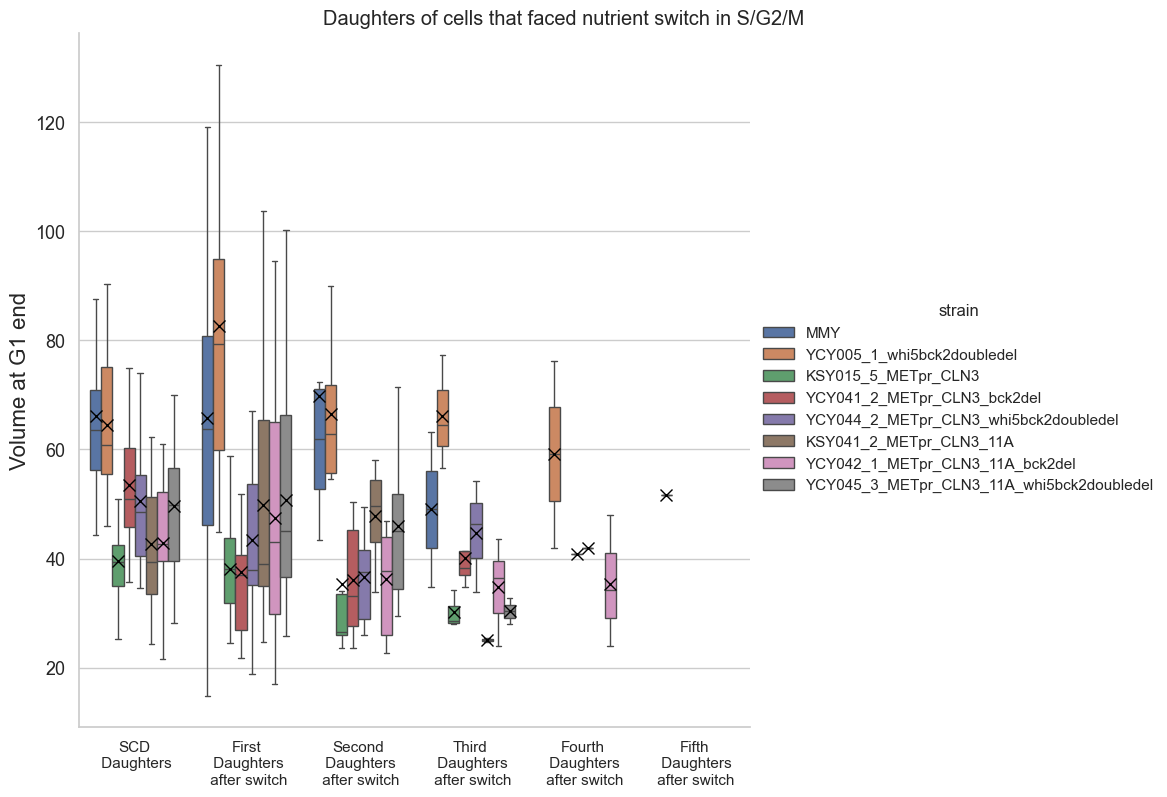

In [17]:
############################### steady state plotting df prep ############################################################################

pre_switch_daughters_complete_G1_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['growthmedium'] == "SCD") 
                                                                                    & (overall_df_with_rel_and_switch_info['generation_num'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
                                                                                   ]
pd.set_option('display.max_rows', 350)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 300)
#display(post_switch_daughters_complete_G1_df.head(20))

#groupby unique f_pos_cell_id

unique_f_pos_cell_id = []
for fposid in ((pre_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_daughters_complete_G1_df[pre_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    last_G1_frame_vol = fposid_df['cell_vol_fl'].iloc[-1]
    fposid_df['last_G1_frame_vol'] = last_G1_frame_vol
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
unique_SCD_daughters_G1_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)
unique_SCD_daughters_G1_plotting_df['S_switch_cells_daughter_wave'] = 0
unique_SCD_daughters_G1_plotting_df['G1_switch_cells_daughter_wave'] = 0

############################### nutrient switch plotting df prep ############################################################################

post_switch_daughters_df = overall_df_with_rel_and_switch_info[(np.isnan(overall_df_with_rel_and_switch_info['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == 1.0)|
                                                                                       (overall_df_with_rel_and_switch_info['post_switch_gen'] == "1"))
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    #& (overall_df_with_rel_and_switch_info['phase_saw_switch'] == False)
                                                                                   ]
print(post_switch_daughters_df.S_switch_cells_daughter_wave.unique())

unique_f_pos_cell_id_2 = []
for fposid in ((post_switch_daughters_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_daughters_df[post_switch_daughters_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    last_G1_frame_vol = fposid_df['cell_vol_fl'].iloc[-1]
    fposid_df['last_G1_frame_vol'] = last_G1_frame_vol
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_nutrient_switch_daughterwaves_G1_plotting_df = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)


preswitch_plus_postswitch = pd.concat([unique_SCD_daughters_G1_plotting_df, unique_nutrient_switch_daughterwaves_G1_plotting_df]).reset_index()

sns.set_style("whitegrid")
a = sns.catplot(x = "S_switch_cells_daughter_wave", y = "last_G1_frame_vol",hue = "strain", data =preswitch_plus_postswitch, 
                kind = "box", 
                #col = "rep",
                #palette = palette, 
                hue_order = ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                height=8, aspect=1, showfliers = False, showmeans = True,
                meanprops={"marker":"x","markerfacecolor":"white", "markeredgecolor":"black", "markeredgewidth":1, "markersize": 8})
a.set_axis_labels("", "Volume at G1 end", size = 16)
a.fig.suptitle("Daughters of cells that faced nutrient switch in S/G2/M")
a.set_xticklabels(['SCD\n Daughters','First\n Daughters\n after switch','Second\n Daughters\n after switch',
                   'Third\n Daughters\n after switch','Fourth\n Daughters\n after switch', 'Fifth\n Daughters\n after switch'])

a.fig.subplots_adjust(top=.95)
a.tick_params(axis='y', labelsize=13)
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Revision\METpr_CLN311A_nutrientswitch\repscombined_daughtersSG2Mswitchers_volatG1end.png", bbox_inches="tight")
plt.show()

# ***Daughters of switchers - G1 lengths - selected strains*** 

In [18]:


############################### nutrient switch SG2M daughters plotting df prep ############################################################################



post_switch_Sdaughters_complete_G1_df = overall_df_with_rel_and_switch_info[(np.isnan(overall_df_with_rel_and_switch_info['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((overall_df_with_rel_and_switch_info['post_switch_gen'] == 1.0)|
                                                                                       (overall_df_with_rel_and_switch_info['post_switch_gen'] == "1.0"))
                                                                                    & (overall_df_with_rel_and_switch_info['cell_cycle_stage'] == "G1")
                                                                                    & (overall_df_with_rel_and_switch_info['complete_phase'] == 1)
                                                                                    & (overall_df_with_rel_and_switch_info['phase_begin'] >= 50)
                                                                                   ]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)
unique_first_G1_frame_df_Sdaughters['phase_length_mins'] = unique_first_G1_frame_df_Sdaughters['phase_length']*3






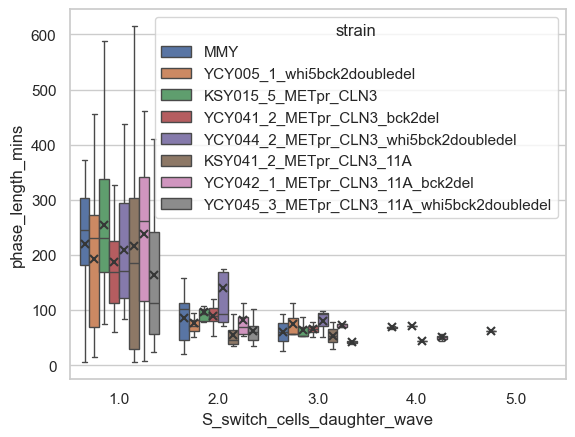

In [19]:

S = sns.boxplot(data=unique_first_G1_frame_df_Sdaughters,
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                #ax = ax3,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order =  ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                #palette = palette,
                #**PROPS
               )
# A = sns.swarmplot(data=unique_first_G1_frame_df_Sdaughters, 
#                        x= "S_switch_cells_daughter_wave", y="phase_length_mins", hue = "strain", 
#                         hue_order =  ['MMY','YCY005_1_whi5bck2doubledel', 'KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
#                         dodge = True, size = 4)
#ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)




# ax1.legend([],[], frameon=False)
# ax2.legend([],[], frameon=False)
# ax3.legend([],[], frameon=False)
# ax4.legend(loc='upper right', bbox_to_anchor=(2, 1))
# ax5.legend([],[], frameon=False)
# ax6.legend([],[], frameon=False)
# ax7.legend([],[], frameon=False)
# ax8.legend(loc='upper right', bbox_to_anchor=(2, 1))

# # xtix = ['G1']
# # ax1.set_xticklabels(xtix, fontsize = 14)
# # ax2.set_xticklabels(xtix, fontsize = 14)
# # ax3.set_xticklabels(xtix, fontsize = 14)
# # ax4.set_xticklabels(xtix, fontsize = 14)


# ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
# ax2.set_xticklabels(['First\n Daughters','Second\n Daughters',
#                    'Third\n Daughters'], fontsize = 13)
#ax3.set_xticklabels(['First\n Daughters','Second\n Daughters',
                   #'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
#ax1.set_xticklabels(['All daughters'], fontsize = 13)
# ax4.set_xticklabels(['All daughters'], fontsize = 13)

# ax5.set_yticklabels(ax5.get_yticklabels(), fontsize = 14)
# ax6.set_xticklabels(['First\n Daughters','Second\n Daughters',
#                    'Third\n Daughters','Fourth\n Daughters'], fontsize = 13)
# ax7.set_xticklabels(['First\n Daughters','Second\n Daughters',
#                    'Third\n Daughters','Fourth\n Daughters', 'Fifth\n Daughters'], fontsize = 13)
# ax5.set_xticklabels(['All daughters'], fontsize = 13)
# ax8.set_xticklabels(['All daughters'], fontsize = 13)

# ax1.set_xlabel("")
# ax2.set_xlabel("")
# ax3.set_xlabel("")
# ax4.set_xlabel("")
# ax5.set_xlabel("")
# ax6.set_xlabel("")
# ax7.set_xlabel("")
# ax8.set_xlabel("")

# S.figure.subplots_adjust(wspace = 0.1)
# A.figure.subplots_adjust(wspace = 0.1)

# sns.despine(ax = ax1)
# sns.despine(ax = ax2)
# sns.despine(ax = ax3)
# sns.despine(ax = ax4)
# sns.despine(ax = ax5)
# sns.despine(ax = ax6)
# sns.despine(ax = ax7)
# sns.despine(ax = ax8)

# ax5.set_ylim(ax1.get_ylim())


# # S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length.svg")
# A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig4\Panel2_daughtersofswitchers_G1_length_swarm.svg")
plt.show()

#  ***Calculate percent ded for each strain over total experiment***

In [20]:
liste = []
for strain in (overall_df_with_rel_and_switch_info['strain'].unique()):
    strain_df = overall_df_with_rel_and_switch_info[overall_df_with_rel_and_switch_info['strain'] == strain]
    #print(strain)
    live = 0
    dead = 0
    total= 0
    for pos in strain_df['position'].unique():
        pos_df = strain_df[strain_df['position'] == pos]
        total_cells_in_pos = (len(pos_df['Cell_ID'].unique()))
        dead_df = pos_df[pos_df['is_cell_dead'] == 1]
        dead_cells_in_pos = (len(dead_df['Cell_ID'].unique()))
        live_cells_in_pos = (total_cells_in_pos - dead_cells_in_pos)
        live = live + live_cells_in_pos
        dead = dead + dead_cells_in_pos
        total = total + total_cells_in_pos
    stuffs = [[strain, total, live, dead]]
    death_row = pd.DataFrame(stuffs, columns =['strain', 'total_cells', 'live_cells', 'dead_cells'])
    liste.append(death_row)
        # print(live, dead, live_cells_in_pos, dead_cells_in_pos)
    # print(total)
    # print("percent dead =")
    # print((dead/total)*100)
death_analysis_df = pd.concat(liste)
death_analysis_df['percent_dead'] = (death_analysis_df['dead_cells']/death_analysis_df['total_cells'])*100
death_analysis_df['percent_live'] = (death_analysis_df['live_cells']/death_analysis_df['total_cells'])*100

display(death_analysis_df)

,strain,total_cells,live_cells,dead_cells,percent_dead,percent_live
0,MMY,315,277,38,12.063492,87.936508
0,YCY005_1_whi5bck2doubledel,320,271,49,15.312500,84.687500
0,KSY015_5_METpr_CLN3,258,210,48,18.604651,81.395349
0,YCY041_2_METpr_CLN3_bck2del,316,287,29,9.177215,90.822785
0,YCY044_2_METpr_CLN3_whi5bck2doubledel,214,179,35,16.355140,83.644860
0,KSY041_2_METpr_CLN3_11A,144,106,38,26.388889,73.611111
0,YCY042_1_METpr_CLN3_11A_bck2del,265,238,27,10.188679,89.811321
0,YCY045_3_METpr_CLN3_11A_whi5bck2doubledel,220,187,33,15.000000,85.000000


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'MMY'),
  Text(1, 0, 'YCY005_1_whi5bck2doubledel'),
  Text(2, 0, 'KSY015_5_METpr_CLN3'),
  Text(3, 0, 'YCY041_2_METpr_CLN3_bck2del'),
  Text(4, 0, 'YCY044_2_METpr_CLN3_whi5bck2doubledel'),
  Text(5, 0, 'KSY041_2_METpr_CLN3_11A'),
  Text(6, 0, 'YCY042_1_METpr_CLN3_11A_bck2del'),
  Text(7, 0, 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel')])

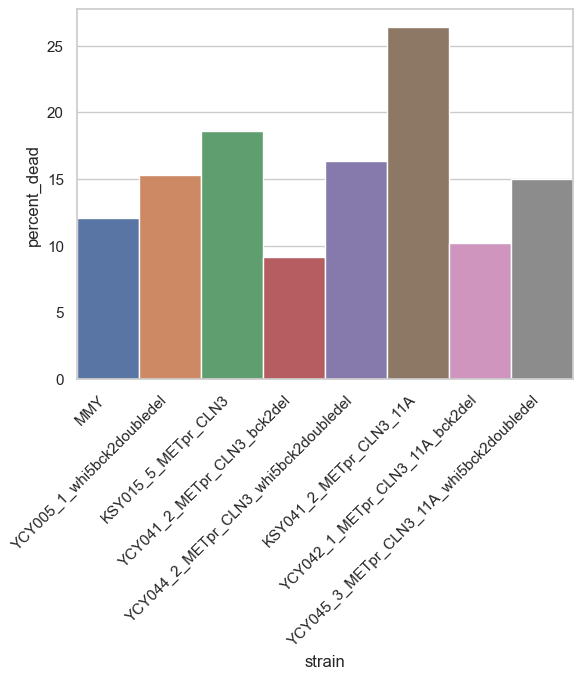

In [21]:
a = sns.barplot(x = "strain", y = "percent_dead", data =death_analysis_df, hue = "strain", width = 1, dodge = False)
plt.xticks(rotation=45, ha = 'right')
#sns.move_legend(a, "upper left", bbox_to_anchor=(1, 1))
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Revision\METpr_CLN311A_nutrientswitch\repscombined_rep2_percentdeadcells.png", bbox_inches="tight")

# ***Revised Fig 7: stabilised and/or overexpressed CLN3 - Daughters of S/G2/M switchers - G1 length and vol at G1 end*** 

In [22]:

############################### nutrient switch SG2M daughters plotting df prep ############################################################################

selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "KSY015_5_METpr_CLN3")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "YCY041_2_METpr_CLN3_bck2del")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "YCY044_2_METpr_CLN3_whi5bck2doubledel")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "KSY041_2_METpr_CLN3_11A")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "YCY042_1_METpr_CLN3_11A_bck2del")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "YCY045_3_METpr_CLN3_11A_whi5bck2doubledel")]

post_switch_Sdaughters_complete_G1_df = selectedstrains_NS_plotting_df[(np.isnan(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave']) == False) 
                                                                                    & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1.0)|
                                                                                       (selectedstrains_NS_plotting_df['post_switch_gen'] == "1"))
                                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                                    & (selectedstrains_NS_plotting_df['phase_begin'] >= 50)]

# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_Sdaughters = []
for fposid in ((post_switch_Sdaughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = post_switch_Sdaughters_complete_G1_df[post_switch_Sdaughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_Sdaughters.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_Sdaughters = pd.concat(unique_f_pos_cell_id_Sdaughters).reset_index(drop = True)


############################### pre-switch steady state dataprep ############################################################################

pre_switch_daughters_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD") 
                                                                    & (selectedstrains_NS_plotting_df['generation_num'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_daughters_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_daughters_complete_G1_df[pre_switch_daughters_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
unique_first_G1_frame_df_pre['S_switch_cells_daughter_wave'] = 0

preswitch_plus_postswitch = pd.concat([unique_first_G1_frame_df_Sdaughters, unique_first_G1_frame_df_pre])
preswitch_plus_postswitch['phase_length_mins'] = (preswitch_plus_postswitch['phase_length'])*3





Group: '['strain', 'S_switch_cells_daughter_wave']'  |  Value: 'phase_length_mins'


C:\Users\timon\AppData\Local\Temp\ipykernel_24944\2029329832.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_24944\2029329832.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_24944\2029329832.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 14)
C:\Users\timon\AppData\Local\Temp\ipykernel_24944\2029329832.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_yticklabels(ax4.get_ytic

,S_switch_cells_daughter_wave,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(YCY042_1_METpr_CLN3_11A_bck2del, 1.0)",16,238.7,261.0,-0.11,0,Shapiro-Wilk,0.763266,True
1,"(KSY041_2_METpr_CLN3_11A, 1.0)",10,216.0,186.0,0.72,0,Shapiro-Wilk,0.210718,True
2,"(YCY044_2_METpr_CLN3_whi5bck2doubledel, 1.0)",15,210.0,171.0,0.74,0,Shapiro-Wilk,0.067002,True
3,"(YCY045_3_METpr_CLN3_11A_whi5bck2doubledel, 1.0)",16,163.5,114.0,0.78,0,Shapiro-Wilk,0.055523,True
4,"(YCY041_2_METpr_CLN3_bck2del, 1.0)",22,187.0,169.5,1.87,1,Shapiro-Wilk,0.001607,False
5,"(KSY015_5_METpr_CLN3, 1.0)",18,254.7,231.0,0.84,0,Shapiro-Wilk,0.169841,True


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0))",18,22,0.0939,0.0818,0.0891,False,False,False,False
1,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.float64(1.0))",18,15,0.3075,0.3186,0.3470,False,False,False,False
2,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('KSY041_2_METpr_CLN3_11A', np.float64(1.0))",18,10,0.6085,0.5613,0.4149,False,False,False,False
3,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY042_1_METpr_CLN3_11A_bck2del', np.float64(1.0))",18,16,0.7393,0.7394,1.0000,False,False,False,False
4,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY045_3_METpr_CLN3_11A_whi5bck2doubledel', np.float64(1.0))",18,16,0.0505,0.0522,0.0490,False,False,True,True
5,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.float64(1.0))",22,15,0.5168,0.5097,0.5359,False,False,False,False
6,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('KSY041_2_METpr_CLN3_11A', np.float64(1.0))",22,10,0.6837,0.5951,1.0000,False,False,False,False
7,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('YCY042_1_METpr_CLN3_11A_bck2del', np.float64(1.0))",22,16,0.2134,0.1881,0.1473,False,False,False,False
8,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('YCY045_3_METpr_CLN3_11A_whi5bck2doubledel', np.float64(1.0))",22,16,0.5346,0.5203,0.3003,False,False,False,False
9,"('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.float64(1.0)) vs ('KSY041_2_METpr_CLN3_11A', np.float64(1.0))",15,10,0.9346,0.9255,0.7391,False,False,False,False



Group: '['strain', 'S_switch_cells_daughter_wave']'  |  Value: 'phase_volume_at_end'


,S_switch_cells_daughter_wave,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(YCY042_1_METpr_CLN3_11A_bck2del, 1.0)",16,47.4,43.0,0.58,0,Shapiro-Wilk,0.274388,True
1,"(KSY041_2_METpr_CLN3_11A, 1.0)",10,49.9,39.0,1.07,0,Shapiro-Wilk,0.093855,True
2,"(YCY044_2_METpr_CLN3_whi5bck2doubledel, 1.0)",15,43.4,37.9,0.27,0,Shapiro-Wilk,0.328404,True
3,"(YCY045_3_METpr_CLN3_11A_whi5bck2doubledel, 1.0)",16,50.7,45.0,0.95,0,Shapiro-Wilk,0.105485,True
4,"(YCY041_2_METpr_CLN3_bck2del, 1.0)",22,37.5,36.9,0.96,2,Shapiro-Wilk,0.040132,False
5,"(KSY015_5_METpr_CLN3, 1.0)",18,38.2,38.1,0.33,0,Shapiro-Wilk,0.705124,True


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0))",18,22,0.8638,0.8680,0.5407,False,False,False,False
1,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.float64(1.0))",18,15,0.2407,0.2210,0.3380,False,False,False,False
2,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('KSY041_2_METpr_CLN3_11A', np.float64(1.0))",18,10,0.1753,0.0803,0.3498,False,False,False,False
3,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY042_1_METpr_CLN3_11A_bck2del', np.float64(1.0))",18,16,0.1554,0.1323,0.4794,False,False,False,False
4,"('KSY015_5_METpr_CLN3', np.float64(1.0)) vs ('YCY045_3_METpr_CLN3_11A_whi5bck2doubledel', np.float64(1.0))",18,16,0.0361,0.0261,0.0473,True,True,True,False
5,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.float64(1.0))",22,15,0.2192,0.2090,0.2217,False,False,False,False
6,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('KSY041_2_METpr_CLN3_11A', np.float64(1.0))",22,10,0.1612,0.0716,0.2003,False,False,False,False
7,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('YCY042_1_METpr_CLN3_11A_bck2del', np.float64(1.0))",22,16,0.1419,0.1055,0.2939,False,False,False,False
8,"('YCY041_2_METpr_CLN3_bck2del', np.float64(1.0)) vs ('YCY045_3_METpr_CLN3_11A_whi5bck2doubledel', np.float64(1.0))",22,16,0.0337,0.0209,0.0298,True,True,True,False
9,"('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.float64(1.0)) vs ('KSY041_2_METpr_CLN3_11A', np.float64(1.0))",15,10,0.4627,0.4106,0.6373,False,False,False,False


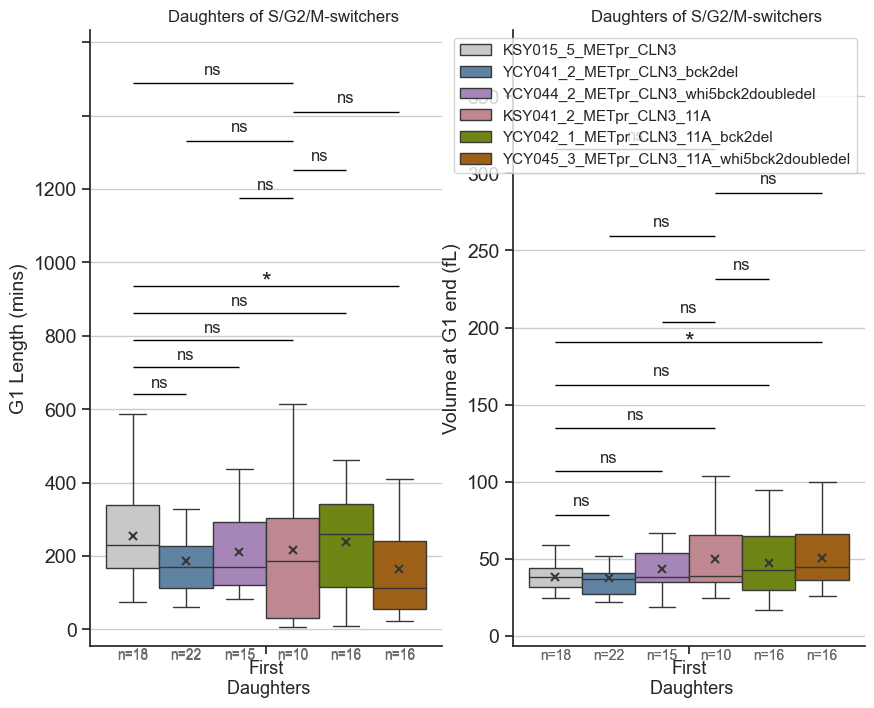

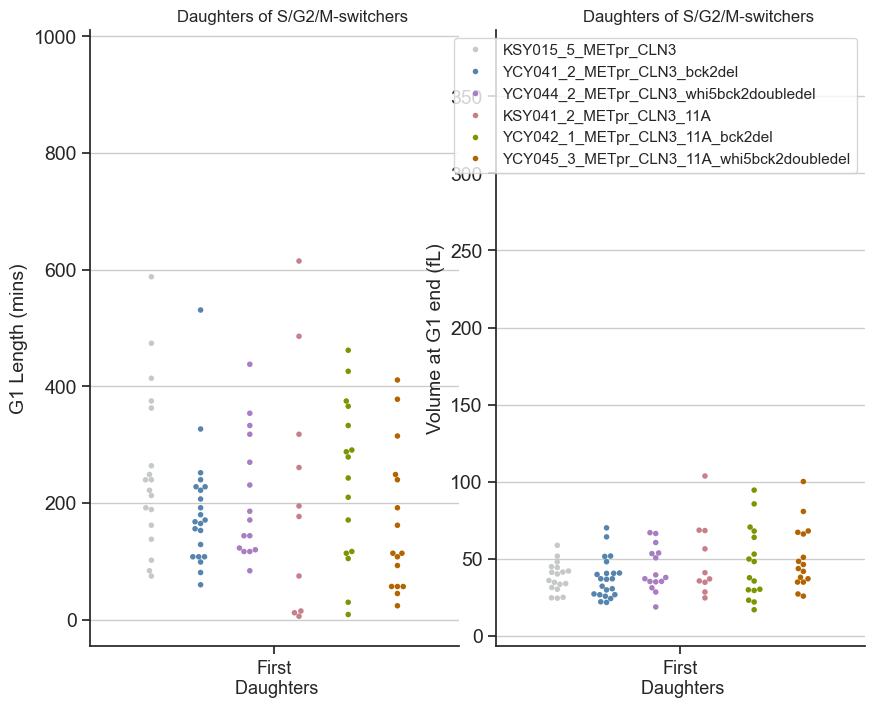

In [ ]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})


palette ={"KSY015_5_METpr_CLN3":"#c5c9c7" ,  "YCY041_2_METpr_CLN3_bck2del": "#5684ae", "YCY044_2_METpr_CLN3_whi5bck2doubledel":"#a87dc2", 
         "KSY041_2_METpr_CLN3_11A":"#c87f89" ,  "YCY042_1_METpr_CLN3_11A_bck2del": "#7a9703", "YCY045_3_METpr_CLN3_11A_whi5bck2doubledel":"#b26400",}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(10, 8))
A, (ax3, ax4) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(10, 8))



S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_length_mins",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1], 
                       x= "S_switch_cells_daughter_wave", y="phase_length_mins", ax = ax3, hue = "strain", 
                        hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                        palette = palette, dodge = True, size = 4)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax1.set_ylabel("")
ax1.set_ylabel("G1 Length (mins)", fontsize = 14)

ax3.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax3.set_ylabel("")
ax3.set_ylabel("G1 Length (mins)", fontsize = 14)

S = sns.boxplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1],
                showmeans = True,
                x= "S_switch_cells_daughter_wave",
                y="phase_volume_at_end",
                ax = ax2,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)

A = sns.swarmplot(data=preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1], 
                       x= "S_switch_cells_daughter_wave", y="phase_volume_at_end", ax = ax4, hue = "strain", 
                        hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                        palette = palette, dodge = True, size = 4)
# sns.swarmplot(x = "S_switch_cells_daughter_wave", y="phase_length_mins",
#                 ax = ax1, hue = "strain", data =preswitch_plus_postswitch, 
#               dodge = True, legend = False, edgecolor = "black", linewidth = 0.5, size = 3, color = 'black')
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == False]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax3, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax2.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax2.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 
ax4.set_title("Daughters of S/G2/M-switchers", fontsize = 12, x=0.55)
ax4.set_ylabel("Volume at G1 end (fL)", fontsize = 14) 


ax1.legend([],[], frameon=False)
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax3.legend([],[], frameon=False)
ax4.legend(loc='upper right', bbox_to_anchor=(1, 1))

ax1.set_ylim(-45.0, 1011.0)
ax3.set_ylim(-45.0, 1011.0)
ax2.set_ylim(-6.542578422970914, 392.9942903645135)
ax4.set_ylim(-6.542578422970914, 392.9942903645135)
ax1.set_xlabel("") 
ax2.set_xlabel("") 
ax3.set_xlabel("") 
ax4.set_xlabel("") 
# xtix = ['G1']
# ax1.set_xticklabels(xtix, fontsize = 14)
# ax2.set_xticklabels(xtix, fontsize = 14)
# ax3.set_xticklabels(xtix, fontsize = 14)
# ax4.set_xticklabels(xtix, fontsize = 14)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 14)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 14)
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 14)
ax4.set_yticklabels(ax4.get_yticklabels(), fontsize = 14)

ax1.set_xticklabels(['First\n Daughters'], fontsize = 13)
ax2.set_xticklabels(['First\n Daughters'], fontsize = 13)
ax3.set_xticklabels(['First\n Daughters'], fontsize = 13)
ax4.set_xticklabels(['First\n Daughters'], fontsize = 13)

plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)
sns.despine(ax = ax2)
sns.despine(ax = ax3)
sns.despine(ax = ax4)

import sys, os, importlib
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
import core
importlib.reload(core)

core.annotate_significance_hue_vs_ref(
      ax = ax1,
      df = preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1],
      x_col = 'S_switch_cells_daughter_wave',
      y_col = 'phase_length_mins',
      hue_col = 'strain',
      x_order = [1],
      hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
      ref_hue = 'KSY015_5_METpr_CLN3',
      test = 'mwu',
)
core.annotate_significance_hue_vs_ref(
      ax = ax1,
      df = preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1],
      x_col = 'S_switch_cells_daughter_wave',
      y_col = 'phase_length_mins',
      hue_col = 'strain',
      x_order = [1],
      hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
      ref_hue = 'KSY041_2_METpr_CLN3_11A',
      test = 'mwu',
      y_gap = 0.5
)
core.annotate_significance_hue_vs_ref(
      ax = ax2,
      df = preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1],
      x_col = 'S_switch_cells_daughter_wave',
      y_col = 'phase_volume_at_end',
      hue_col = 'strain',
      x_order = [1],
      hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
      ref_hue = 'KSY015_5_METpr_CLN3',
      test = 'mwu',
)
core.annotate_significance_hue_vs_ref(
      ax = ax2,
      df = preswitch_plus_postswitch[preswitch_plus_postswitch['S_switch_cells_daughter_wave'] == 1],
      x_col = 'S_switch_cells_daughter_wave',
      y_col = 'phase_volume_at_end',
      hue_col = 'strain',
      x_order = [1],
      hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
      ref_hue = 'KSY041_2_METpr_CLN3_11A',
      test = 'mwu',
      y_gap = 0.25
)

#S.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Revision\METpr_CLN311A_nutrientswitch\Revised_Fig7_Panel5and6_daughtersofSswitchers_G1_length_and_volatG1end.svg")
#A.figure.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Revision\METpr_CLN311A_nutrientswitch\Revised_Fig7_Panel5and6_daughtersofSswitchers_G1_length_and_volatG1end_swarm.svg")
plt.show()

In [24]:
from scipy import stats as scipystats
print("Fig 7E stats: S-switchers first daughters")
METpr_CLN3_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "KSY015_5_METpr_CLN3") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
METpr_CLN3_bck2del_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "YCY041_2_METpr_CLN3_bck2del") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
METpr_CLN3_whi5bck2doubledel_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "YCY044_2_METpr_CLN3_whi5bck2doubledel") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
METpr_CLN3_11A_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "KSY041_2_METpr_CLN3_11A") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
METpr_CLN3_11A_bck2del_df = preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "YCY042_1_METpr_CLN3_11A_bck2del") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]
METpr_CLN3_11A_whi5bck2doubledel_df =  preswitch_plus_postswitch[(preswitch_plus_postswitch["strain"] == "YCY045_3_METpr_CLN3_11A_whi5bck2doubledel") & (preswitch_plus_postswitch["S_switch_cells_daughter_wave"] == 1)]

print("KSY015_5_METpr_CLN3 n", len(METpr_CLN3_df))
print("YCY041_2_METpr_CLN3_bck2del n", len(METpr_CLN3_bck2del_df))
print("YCY044_2_METpr_CLN3_whi5bck2doubledel n", len(METpr_CLN3_whi5bck2doubledel_df))
print("KSY041_2_METpr_CLN3_11A n", len(METpr_CLN3_11A_df))
print("YCY042_1_METpr_CLN3_11A_bck2del n", len(METpr_CLN3_11A_bck2del_df))
print("YCY045_3_METpr_CLN3_11A_whi5bck2doubledel n", len(METpr_CLN3_11A_whi5bck2doubledel_df))


print("\nMETpr_CLN3: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_df["phase_length_mins"]), (METpr_CLN3_bck2del_df["phase_length_mins"]), equal_var = False))
print("METpr_CLN3: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_df["phase_length_mins"]), (METpr_CLN3_whi5bck2doubledel_df["phase_length_mins"]), equal_var = False))
print("METpr_CLN3_11A: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_11A_df["phase_length_mins"]), (METpr_CLN3_11A_bck2del_df["phase_length_mins"]), equal_var = False))
print("METpr_CLN3_11A: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_11A_df["phase_length_mins"]), (METpr_CLN3_11A_whi5bck2doubledel_df["phase_length_mins"]), equal_var = False))

print("\nFig 7F stats: S-switchers first daughters")

print("METpr_CLN3: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_df["phase_volume_at_end"]), (METpr_CLN3_bck2del_df["phase_volume_at_end"]), equal_var = False))
print("METpr_CLN3: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_df["phase_volume_at_end"]), (METpr_CLN3_whi5bck2doubledel_df["phase_volume_at_end"]), equal_var = False))
print("METpr_CLN3_11A: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_11A_df["phase_volume_at_end"]), (METpr_CLN3_11A_bck2del_df["phase_volume_at_end"]), equal_var = False))
print("METpr_CLN3_11A: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_11A_df["phase_volume_at_end"]), (METpr_CLN3_11A_whi5bck2doubledel_df["phase_volume_at_end"]), equal_var = False))


Fig 7E stats: S-switchers first daughters
KSY015_5_METpr_CLN3 n 18
YCY041_2_METpr_CLN3_bck2del n 22
YCY044_2_METpr_CLN3_whi5bck2doubledel n 15
KSY041_2_METpr_CLN3_11A n 10
YCY042_1_METpr_CLN3_11A_bck2del n 16
YCY045_3_METpr_CLN3_11A_whi5bck2doubledel n 16

METpr_CLN3: WT VS BCK2 TtestResult(statistic=np.float64(1.730112215572095), pvalue=np.float64(0.09386175453365025), df=np.float64(30.074406833550025))
METpr_CLN3: WT VS whi5bck2dd TtestResult(statistic=np.float64(1.0375258892739643), pvalue=np.float64(0.30754989199226673), df=np.float64(30.870029584073468))
METpr_CLN3_11A: WT VS BCK2 TtestResult(statistic=np.float64(-0.30453369494033244), pvalue=np.float64(0.7652155590135168), df=np.float64(13.954725957546636))
METpr_CLN3_11A: WT VS whi5bck2dd TtestResult(statistic=np.float64(0.7213369311739095), pvalue=np.float64(0.4835507306087733), df=np.float64(12.921422556550917))

Fig 7F stats: S-switchers first daughters
METpr_CLN3: WT VS BCK2 TtestResult(statistic=np.float64(0.172775902067968

# ***Fig 7A: Birth volume pre-switch steady state cells*** 

In [39]:
############################### pre-switch steady state dataprep ############################################################################

pre_switch_complete_G1_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['growthmedium'] == "SCD")
                                                                    & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                                    & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                                    & (selectedstrains_NS_plotting_df['phase_saw_switch'] == False)
                                                                    ]
# getting only the first frame of G1 for every cell
unique_f_pos_cell_id_2 = []
for fposid in ((pre_switch_complete_G1_df['f_pos_cell_id']).unique()):
    fposid_df = pre_switch_complete_G1_df[pre_switch_complete_G1_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Cell_ID'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
unique_first_G1_frame_df_pre = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)




Group: '['strain', 'daughterhood_binary']'  |  Value: 'cell_vol_fl'


C:\Users\timon\AppData\Local\Temp\ipykernel_24944\2472650859.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Mothers','Daughters'], fontsize = 17)


,daughterhood_binary,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(KSY015_5_METpr_CLN3, 0)",44,56.9,54.6,0.44,0,Shapiro-Wilk,1.706390e-01,True
1,"(YCY041_2_METpr_CLN3_bck2del, 0)",44,77.2,73.0,1.17,2,Shapiro-Wilk,4.139441e-03,False
2,"(YCY042_1_METpr_CLN3_11A_bck2del, 1)",20,37.3,37.7,-0.42,0,Shapiro-Wilk,7.347551e-01,True
3,"(KSY041_2_METpr_CLN3_11A, 1)",21,37.6,35.0,0.24,0,Shapiro-Wilk,2.177228e-01,True
4,"(YCY044_2_METpr_CLN3_whi5bck2doubledel, 1)",19,44.3,41.9,0.99,1,Shapiro-Wilk,1.227343e-02,False
5,"(KSY041_2_METpr_CLN3_11A, 0)",30,74.2,63.0,2.61,2,Shapiro-Wilk,3.937000e-07,False
6,"(YCY045_3_METpr_CLN3_11A_whi5bck2doubledel, 1)",23,44.0,43.7,0.90,1,Shapiro-Wilk,2.313605e-01,True
7,"(YCY042_1_METpr_CLN3_11A_bck2del, 0)",22,67.1,61.0,1.43,2,Shapiro-Wilk,2.535630e-03,False
8,"(YCY041_2_METpr_CLN3_bck2del, 1)",32,45.9,43.4,2.14,1,Shapiro-Wilk,8.691900e-05,False
9,"(YCY045_3_METpr_CLN3_11A_whi5bck2doubledel, 0)",30,82.5,79.4,2.40,1,Shapiro-Wilk,2.158020e-05,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('KSY015_5_METpr_CLN3', np.int64(0))",36,44,0.0000,0.0000,0.0000,True,True,True,False
1,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('YCY041_2_METpr_CLN3_bck2del', np.int64(1))",36,32,0.0002,0.0001,0.0000,True,True,True,False
2,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('YCY041_2_METpr_CLN3_bck2del', np.int64(0))",36,44,0.0000,0.0000,0.0000,True,True,True,False
3,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.int64(1))",36,19,0.0038,0.0007,0.0011,True,True,True,False
4,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('YCY044_2_METpr_CLN3_whi5bck2doubledel', np.int64(0))",36,26,0.0000,0.0000,0.0000,True,True,True,False
5,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('KSY041_2_METpr_CLN3_11A', np.int64(1))",36,21,0.1947,0.1673,0.2860,False,False,False,False
6,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('KSY041_2_METpr_CLN3_11A', np.int64(0))",36,30,0.0000,0.0000,0.0000,True,True,True,False
7,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('YCY042_1_METpr_CLN3_11A_bck2del', np.int64(1))",36,20,0.2193,0.1992,0.0955,False,False,False,False
8,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('YCY042_1_METpr_CLN3_11A_bck2del', np.int64(0))",36,22,0.0000,0.0000,0.0000,True,True,True,False
9,"('KSY015_5_METpr_CLN3', np.int64(1)) vs ('YCY045_3_METpr_CLN3_11A_whi5bck2doubledel', np.int64(1))",36,23,0.0041,0.0012,0.0031,True,True,True,False


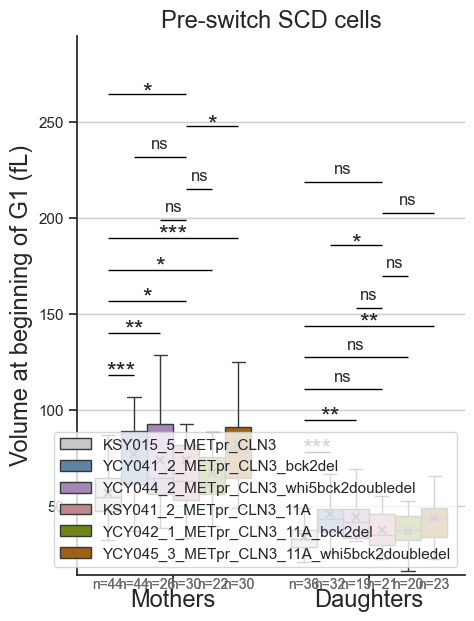

In [41]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"KSY015_5_METpr_CLN3":"#c5c9c7" ,  "YCY041_2_METpr_CLN3_bck2del": "#5684ae", "YCY044_2_METpr_CLN3_whi5bck2doubledel":"#a87dc2", 
         "KSY041_2_METpr_CLN3_11A":"#c87f89" ,  "YCY042_1_METpr_CLN3_11A_bck2del": "#7a9703", "YCY045_3_METpr_CLN3_11A_whi5bck2doubledel":"#b26400",}
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

S, (ax1) = plt.subplots(nrows=1, ncols=1, sharex= False, sharey= True, figsize=(5, 7))


S = sns.boxplot(data=unique_first_G1_frame_df_pre,
                showmeans = True,
                x= "daughterhood_binary",
                y="cell_vol_fl",
                ax = ax1,
                hue = "strain",
                showfliers = False,
                width = 0.8,
                hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                palette = palette,
                **PROPS)
# S = sns.swarmplot(data=(unique_phase_first_frame_df[unique_phase_first_frame_df['cell_saw_switch_in_G1'] == True]), 
#                        x= "cell_cycle_stage", y="phase_length_mins", ax = ax2, hue = "strain", color = "black", dodge = True,edgecolor = "black", linewidth = 0.5, size = 3)
ax1.set_title("Pre-switch SCD cells", fontsize = 17)
ax1.set_ylabel("")
ax1.set_ylabel("Volume at beginning of G1 (fL)", fontsize = 17)

ax1.legend(loc='lower right')
ax1.set_xticklabels(['Mothers','Daughters'], fontsize = 17)
#ax1.set_yticklabels(ax1.get_yticklabels(), fontsize = 17)
ax1.set_xlabel("")

ax1.set_ylim(14.333313901295048, 248.33864511609664)

# plt.subplots_adjust(wspace = 0.1)

sns.despine(ax = ax1)

core.run_stats(
      unique_first_G1_frame_df_pre,
      value_cols = ['cell_vol_fl'],
      group_col = ['strain', 'daughterhood_binary']
)

core.annotate_significance_hue_vs_ref(
      ax = ax1,
      df = unique_first_G1_frame_df_pre,
      x_col = 'daughterhood_binary',
      y_col = 'cell_vol_fl',
      hue_col = 'strain',
      x_order = [0, 1],
      hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
      ref_hue = 'KSY015_5_METpr_CLN3',
      test = 'mwu',
)
core.annotate_significance_hue_vs_ref(
      ax = ax1,
      df = unique_first_G1_frame_df_pre,
      x_col = 'daughterhood_binary',
      y_col = 'cell_vol_fl',
      hue_col = 'strain',
      x_order = [0, 1],
      hue_order = ['KSY015_5_METpr_CLN3','YCY041_2_METpr_CLN3_bck2del' ,'YCY044_2_METpr_CLN3_whi5bck2doubledel', 'KSY041_2_METpr_CLN3_11A', 'YCY042_1_METpr_CLN3_11A_bck2del', 'YCY045_3_METpr_CLN3_11A_whi5bck2doubledel'],
      ref_hue = 'KSY041_2_METpr_CLN3_11A',
      test = 'mwu',
      y_gap = 0.3

)
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Revision\METpr_CLN311A_nutrientswitch\Revised_Fig7_Panel4_preswitchcells_vol_at_birth.svg")
plt.show()

In [27]:
print("Fig 7D stats- pre-switch mothers:")
METpr_CLN3_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "KSY015_5_METpr_CLN3") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
METpr_CLN3_bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY041_2_METpr_CLN3_bck2del") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
METpr_CLN3_whi5bck2doubledel_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY044_2_METpr_CLN3_whi5bck2doubledel") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
METpr_CLN3_11A_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "KSY041_2_METpr_CLN3_11A") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
METpr_CLN3_11A_bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY042_1_METpr_CLN3_11A_bck2del") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]
METpr_CLN3_11A_whi5bck2doubledel_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY045_3_METpr_CLN3_11A_whi5bck2doubledel") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 0)]

print("KSY015_5_METpr_CLN3 n", len(METpr_CLN3_df))
print("YCY041_2_METpr_CLN3_bck2del n", len(METpr_CLN3_bck2del_df))
print("YCY044_2_METpr_CLN3_whi5bck2doubledel n", len(METpr_CLN3_whi5bck2doubledel_df))
print("KSY041_2_METpr_CLN3_11A n", len(METpr_CLN3_11A_df))
print("YCY042_1_METpr_CLN3_11A_bck2del n", len(METpr_CLN3_11A_bck2del_df))
print("YCY045_3_METpr_CLN3_11A_whi5bck2doubledel n", len(METpr_CLN3_11A_whi5bck2doubledel_df))


print("\nMETpr_CLN3: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_df["cell_vol_fl"]), (METpr_CLN3_bck2del_df["cell_vol_fl"]), equal_var = False))
print("METpr_CLN3: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_df["cell_vol_fl"]), (METpr_CLN3_whi5bck2doubledel_df["cell_vol_fl"]), equal_var = False))
print("METpr_CLN3_11A: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_11A_df["cell_vol_fl"]), (METpr_CLN3_11A_bck2del_df["cell_vol_fl"]), equal_var = False))
print("METpr_CLN3_11A: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_11A_df["cell_vol_fl"]), (METpr_CLN3_11A_whi5bck2doubledel_df["cell_vol_fl"]), equal_var = False))

print("Fig 7D stats pre-switch daughters:")
METpr_CLN3_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "KSY015_5_METpr_CLN3") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
METpr_CLN3_bck2del_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY041_2_METpr_CLN3_bck2del") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
METpr_CLN3_whi5bck2doubledel_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY044_2_METpr_CLN3_whi5bck2doubledel") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
METpr_CLN3_11A_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "KSY041_2_METpr_CLN3_11A") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
METpr_CLN3_11A_bck2del_df =  unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY042_1_METpr_CLN3_11A_bck2del") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]
METpr_CLN3_11A_whi5bck2doubledel_df = unique_first_G1_frame_df_pre[(unique_first_G1_frame_df_pre["strain"] == "YCY045_3_METpr_CLN3_11A_whi5bck2doubledel") & (unique_first_G1_frame_df_pre["daughterhood_binary"] == 1)]

print("KSY015_5_METpr_CLN3 n", len(METpr_CLN3_df))
print("YCY041_2_METpr_CLN3_bck2del n", len(METpr_CLN3_bck2del_df))
print("YCY044_2_METpr_CLN3_whi5bck2doubledel n", len(METpr_CLN3_whi5bck2doubledel_df))
print("KSY041_2_METpr_CLN3_11A n", len(METpr_CLN3_11A_df))
print("YCY042_1_METpr_CLN3_11A_bck2del n", len(METpr_CLN3_11A_bck2del_df))
print("YCY045_3_METpr_CLN3_11A_whi5bck2doubledel n", len(METpr_CLN3_11A_whi5bck2doubledel_df))

print("\nMETpr_CLN3: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_df["cell_vol_fl"]), (METpr_CLN3_bck2del_df["cell_vol_fl"]), equal_var = False))
print("METpr_CLN3: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_df["cell_vol_fl"]), (METpr_CLN3_whi5bck2doubledel_df["cell_vol_fl"]), equal_var = False))
print("METpr_CLN3_11A: WT VS BCK2",scipystats.ttest_ind((METpr_CLN3_11A_df["cell_vol_fl"]), (METpr_CLN3_11A_bck2del_df["cell_vol_fl"]), equal_var = False))
print("METpr_CLN3_11A: WT VS whi5bck2dd",scipystats.ttest_ind((METpr_CLN3_11A_df["cell_vol_fl"]), (METpr_CLN3_11A_whi5bck2doubledel_df["cell_vol_fl"]), equal_var = False))


Fig 7D stats- pre-switch mothers:
KSY015_5_METpr_CLN3 n 44
YCY041_2_METpr_CLN3_bck2del n 44
YCY044_2_METpr_CLN3_whi5bck2doubledel n 26
KSY041_2_METpr_CLN3_11A n 30
YCY042_1_METpr_CLN3_11A_bck2del n 22
YCY045_3_METpr_CLN3_11A_whi5bck2doubledel n 30

METpr_CLN3: WT VS BCK2 TtestResult(statistic=np.float64(-4.788007041452602), pvalue=np.float64(9.511157189694755e-06), df=np.float64(67.81407912306653))
METpr_CLN3: WT VS whi5bck2dd TtestResult(statistic=np.float64(-3.3847131592321293), pvalue=np.float64(0.0017536246340590534), df=np.float64(35.44495707654347))
METpr_CLN3_11A: WT VS BCK2 TtestResult(statistic=np.float64(0.8311323405155973), pvalue=np.float64(0.4103470329976152), df=np.float64(44.392714451707874))
METpr_CLN3_11A: WT VS whi5bck2dd TtestResult(statistic=np.float64(-0.8985271430953639), pvalue=np.float64(0.37293704823659435), df=np.float64(53.416744338663904))
Fig 7D stats pre-switch daughters:
KSY015_5_METpr_CLN3 n 36
YCY041_2_METpr_CLN3_bck2del n 32
YCY044_2_METpr_CLN3_whi5bck